# Loan Default Prediction

In [ ]:
%load_ext autoreload
%autoreload 2

In [36]:
# Run everytime a new function is added
from scripts.utilities import *
from scripts.features import *

In [2]:
consumer_df, account_df, transaction_df = get_data()

Data successfully loaded and processed.


In [27]:
# Comment unneeded features
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
]

In [28]:
# Calculate features
feature_dataframes = [fn(account_df, transaction_df) for fn in selected_features]

In [29]:
# DataFrame of id and all the created featues
final_features = merge_features(feature_dataframes)

Shape is:  (12647, 7)


In [51]:
# Merge features into consumer_df and handle scoring exclusions if needed
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)
train_df, val_df, test_df = split_data(ml_features, test_size=0.25, val_size=None)

Training set size: 9000
No validation set created.
Test set size: 3000


In [48]:
# Exclude columns: prism_consumer_id, evaluation_date, credit_score, and DQ_TARGET
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
feature_columns = [col for col in train_df.columns if col not in exclude_columns]

In [49]:
model = train_logistic_regression(train_df, feature_columns)

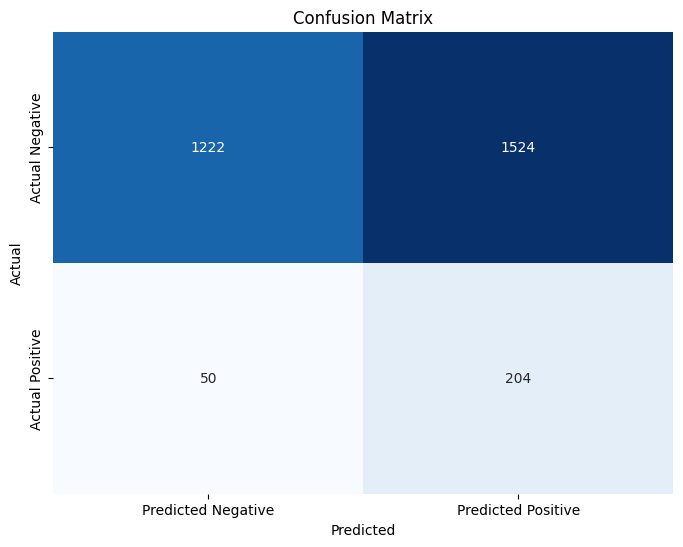

Accuracy: 0.47533333333333333
ROC AUC Score: 0.6790005218757706
Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1222                1524
Actual Positive                  50                 204


In [50]:
predict_and_analyze_model(model, test_df, feature_columns)